In [1]:
# Enable Debugging

%load_ext autoreload
%autoreload 2

In [2]:
#
# Import the campaign diagram class
#
import sys
import os

sys.path.append(os.path.abspath("../../"))
from campaign_diagram import *


In [3]:
# Example usage with multiple Kernel instances

kernel1a = Kernel(name='EinsumA',
                  start=0,
                  duration=3,
                  compute_util=0.7,
                  bw_util=0.25)

kernel1b = Kernel(name='EinsumB',
                  start=kernel1a.end,
                  duration=10,
                  compute_util=0.2,
                  bw_util=0.9)

kernel1c = Kernel(name='EinsumC',
                  start=kernel1b.end,
                  duration=2,
                  compute_util=0.6,
                  bw_util=0.4)

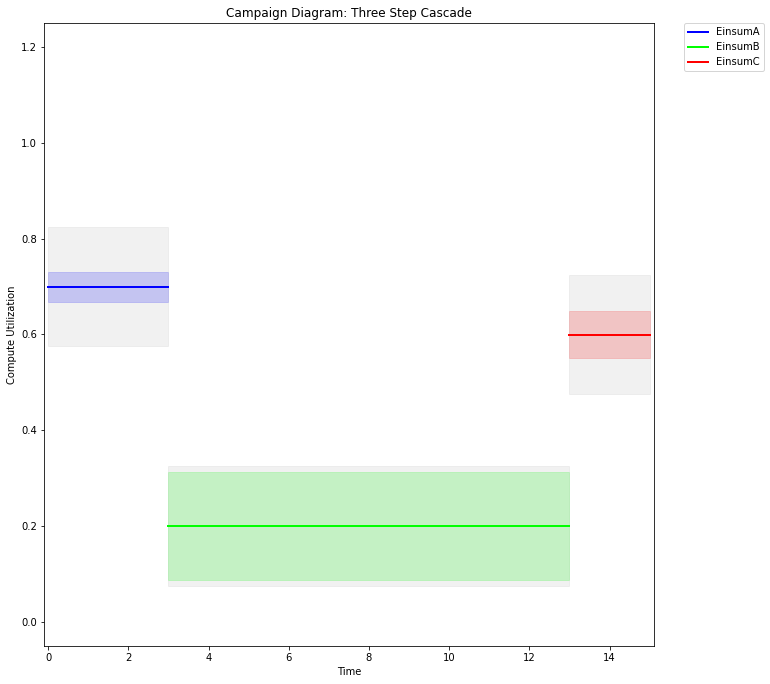

Cascade duration: 15.00
Cascade average compute utilization: 0.35
Cascade average bw utilization: 0.70


In [4]:
# Create the plot with a list of kernel instances

cascade1 = Cascade(name="Three Step Cascade",
                   kernels=[kernel1a, kernel1b, kernel1c])

CampaignDiagram(cascade1).draw()

In [5]:
# Define kernels for pipeline example

repeat = 4

kernel2a = Kernel(name='EinsumA',
                  start=0,
                  duration=5,
                  compute_util=0.8,
                  bw_util=0.2)


kernel2b = Kernel(name='EinsumB',
                  start=kernel2a.end,
                  duration=10,
                  compute_util=0.2,
                  bw_util=0.6)

original_cascade = Cascade(name="Two-step Cascade",
                           kernels=[kernel2a, kernel2b])



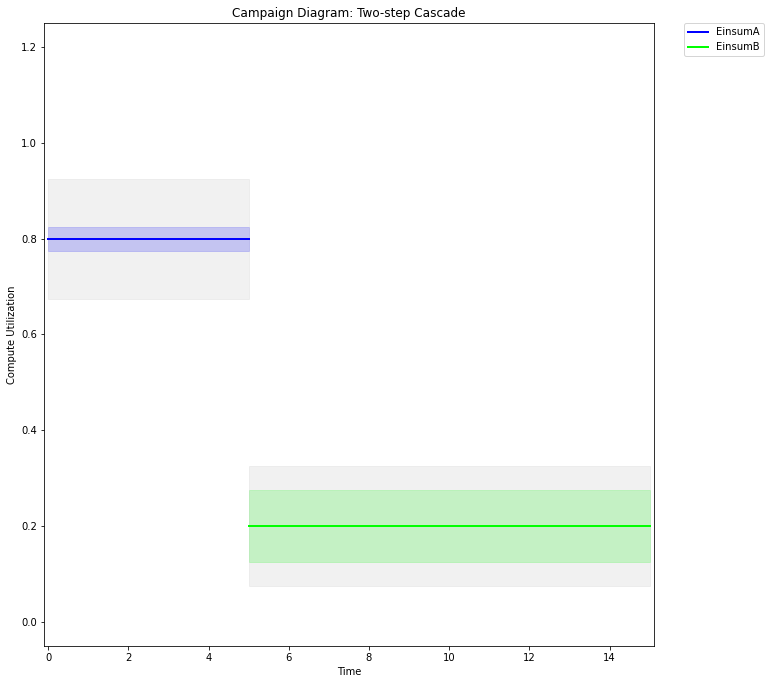

Cascade duration: 15.00
Cascade average compute utilization: 0.40
Cascade average bw utilization: 0.47


In [6]:
CampaignDiagram(original_cascade).draw()

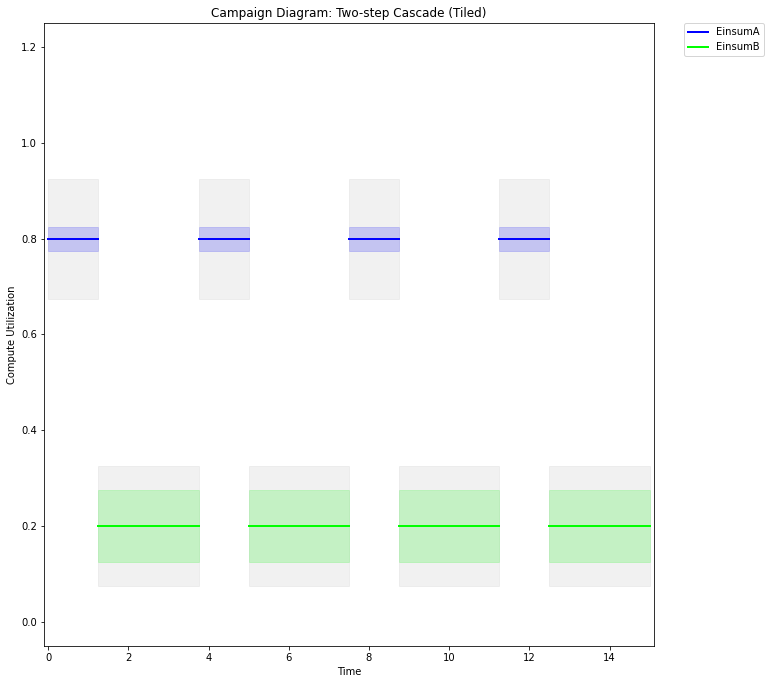

Cascade duration: 15.00
Cascade average compute utilization: 0.40
Cascade average bw utilization: 0.47


In [7]:
# Unpipelined processing

tiled_cascade = original_cascade.tile(repeat)
CampaignDiagram(tiled_cascade).draw()

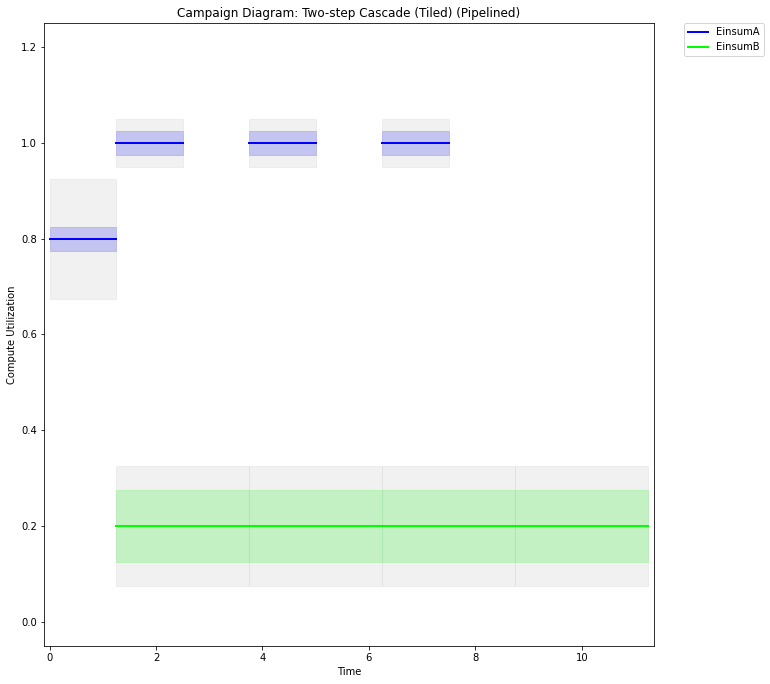

Cascade duration: 11.25
Cascade average compute utilization: 0.53
Cascade average bw utilization: 0.62


In [8]:
# Pipelined diagram (undilated)

pipelined_cascade = tiled_cascade.pipeline()

CampaignDiagram(pipelined_cascade).draw()

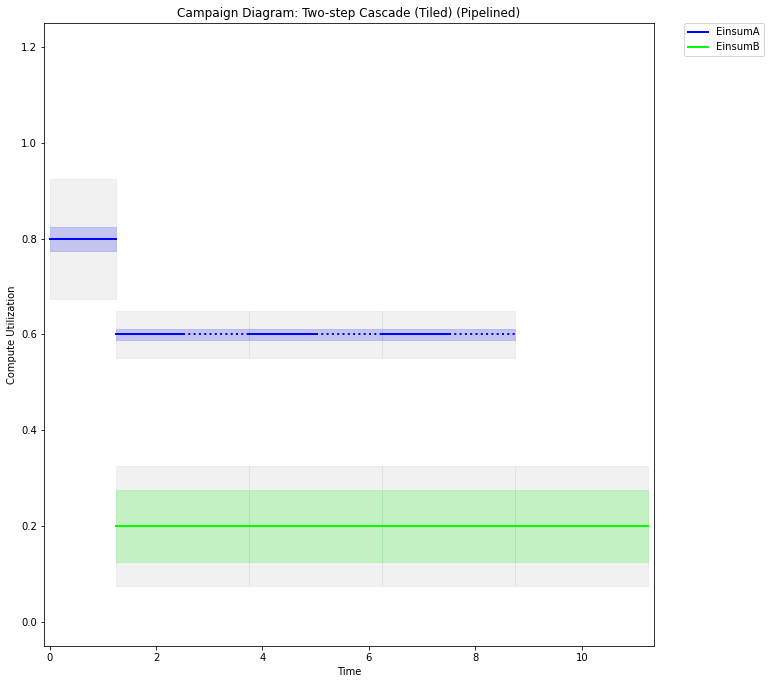

Cascade duration: 11.25
Cascade average compute utilization: 0.53
Cascade average bw utilization: 0.62


In [9]:
# Pipelined diagram (dilated)

pipelined_cascade2 = tiled_cascade.pipeline(spread=True)
    
CampaignDiagram(pipelined_cascade2).draw()